# Data Preparation

The following code block reads the [CSV file for VCQ](https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv) into a DataFrame object. It then creates a new DataFrame object to focus on questions from the Family Satisfaction section of the survey. It is important to run this code block before working on the rest of the notebook.
Refer to the [VCQ code book](https://docs.google.com/document/d/1uYfUuUsPVQyD3puVvbIMjamYuVPr_f4gtJuSB5Wj-WA/edit) for questions that match the columns in the following dataset.


In [1]:
#Collect data into a DataFrame object
import pandas as pd
raw_df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv')
family_df = raw_df.filter(regex='^family').copy()
family_df.columns = family_df.columns.str.removeprefix('family_')
family_df.head()

,enjoy,stress,sacrifices,like,secrets,fight,regularly
0,6.0,5.0,6.0,6.0,6.0,4.0,6.0
1,6.0,3.0,6.0,6.0,4.0,3.0,5.0
2,6.0,1.0,6.0,6.0,3.0,2.0,3.0
3,6.0,5.0,6.0,6.0,4.0,3.0,6.0
4,6.0,4.0,4.0,6.0,4.0,3.0,5.0


## Practice

In [ ]:
# Create a new DataFrame object called deviance_df to hold columns related to the questions in the Deviance section.

# Remove the 'deviance_' prefix from the column names of deviance_df.

# Call the head function to show a few rows from deviance_df


# Initial data exploration

The describe function can be used to provide a quick understanding of how students answer these questions.

In [ ]:
pd.set_option('display.float_format', '{:.1f}'.format)
family_df.describe()

,enjoy,stress,sacrifices,like,secrets,fight,regularly
count,542.0,542.0,541.0,542.0,541.0,539.0,542.0
mean,5.2,3.8,5.2,5.4,4.0,3.2,4.4
std,1.0,1.4,0.9,0.8,1.4,1.4,1.4
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,5.0,3.0,5.0,5.0,3.0,2.0,4.0
50%,5.0,4.0,5.0,6.0,4.0,3.0,5.0
75%,6.0,5.0,6.0,6.0,5.0,4.0,5.0
max,6.0,6.0,6.0,6.0,6.0,6.0,6.0


From the above descriptive statistics, we can observe as few things about the data:

*  Not everyone answer all questions in this section (542, 541, 539).
*  The average for the `'enjoy'` column is higher than the average for the `'stress'` column, indicating more students agreed with 'I enjoy spending time with my family' than 'my family stresses me out'.
*  Overwhelming majority of students enjoyed spending time with their family, were willing to make sacrifies for their families, and liked their families.
*  The `like` column has the lowest standard deviation, indicating the least variation among how students like their families.

A histogram can be used to share the distribution of student responses for each question.

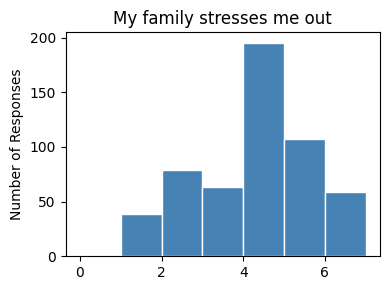

In [2]:
import matplotlib.pyplot as plt     # import appropriate library

# create the histogram
family_df.plot(kind='hist', y='stress',
                  figsize=(4, 3),
                  title='My family stresses me out',
                  ylabel='Number of Responses',
                  bins=7,
                  range=(0, 7),
                  color='steelblue',
                  edgecolor='white',
                  legend=False
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

From the above histogram, we can observe the following. As a reminder, in histogram, the right boundaries are exclusive.

*  Near 200 students somewhat agreed that their families stressed them out.
*  A bit over 50 students strongly agreed that their families stressed them out.
*  Almost 50 students strongly disagreed that their families stressed them out.
*  The distribution is slightly skewed to the right.

A scatter plot can be used to show potential relationship between two questions.

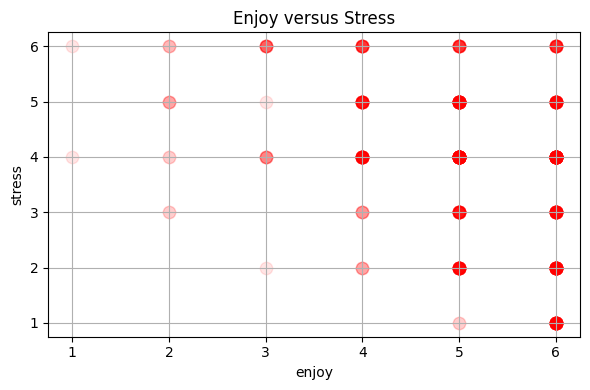

In [3]:
import matplotlib.pyplot as plt     # import appropriate library

# create a scatter plot
family_df.plot(kind='scatter',             #Indicate the kind of plot to be generated
        x='enjoy',            #Identify the column for the x_axis
        y='stress',             #Identify the column for the y-axis
        figsize=(6, 4),             #Set up the width and height of the graph
        title='Enjoy versus Stress',  #Set up the title of the graph
        s=80,                       #Indicate the size of each dot
        alpha=0.1,                  #Indicate the level of transparency
        color='red',                #Indicate the color for the dots
        grid=True                   #Decide whether to use grid
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

From the above scatter plot, we can observe the following:

*  Each dot represents one student. There are overlapping dots. The lighter the dot, the less number of students shared the same answer.
*  The top-left dot is light, indicating one or a few students strongly disagreed with the enjoy question and strongly agreed with the stress question.
*  The bottom-right dot is dark, indicating many students strongly agreed with the enjoy question and strongly disagreed with the stress question.

## Practice

In [ ]:
# Call the describe function to generate descriptive statistics for the columns in deviance_df


In [ ]:
# Choose a column from deviance_df to create a histogram


In [ ]:
# Choose two columns from deviance_df to create a scatter plot


**Add a text block** to communicate key observations about the data using results from the above exercises.

# Recode Responses

According to the [VCQ code book](https://docs.google.com/document/d/1uYfUuUsPVQyD3puVvbIMjamYuVPr_f4gtJuSB5Wj-WA/edit), there are **seven** statements related to the level of family satisfaction. Respondents were asked to answer how much they agree/disagree with each statement. The scale ranges from 1 for strongly disagree to 6 for strong agree. Dr. Trinidad used the following columns for these questions:

*  **family_enjoy**: I enjoy spending time with my family (9a).
*  **family_stress**: My family stresses me out (R9b).
*  **family_sacrifieces**: I am willing to make sacrifices for my family (9c).
*  **family_like**: I like my family (9d).
*  **family_secrets**: I keep secrets from my family (R9e).
*  **family_fight**: I often fight with my family (R9f).
*  **family_regularly**: I regularly spend time with my family (9g).

Some of these statements were worded in a way that a **higher** score in this item implies **more** family satisfaction and a **lower** score implies **less** family satisfaction. For example,
*  The more a student agreed with the statement *"I enjoy spending time with my family"*, i.e. the higher value in `family_enjoy`, the more likely the respondent was satisfied with their family.
*  The more a student disagreed with the statement that `"I like my family"`, i.e. the lower value in `family_like`, the less likely the respondent was satisfaied with their family.

We call these **positively worded statements**.

On the other hand, some of these statements were worded in a way that a **higher** score for this item implies **less** family satisfaction and a **lower** score implies **more** family satisfaction. For example,
*  The more a student agreed with the statement *"My family stresses me out"*, i.e. the higher value in `family_stress`, the less likely the respondent was satisfied with their family.
*  The more a respondent disagreed with the statement "I often fight with my family", i.e. the lower value in family_fight, the more likely the respondent was satisfied with their family.

We call these **negatively worded statements**.

As shown in the code book, Dr. Trinidad marked these questions with an R in front of it. we will need to **recode** the responses for these questions by
*  changing the response value of 1 to 6 , (this can be done by 7 - 1)
*  changing the response value of 2 (disagree) to 5 (agree), (this can be done by 7 - 2)
*  changing the response value of 3 to 4, (this can be done by 7 - 3)
*  changing the response value of 4 to 3, (this can be done by 7 - 4)
*  changing the response value of 5 to 2, (this can be done by 7 - 5)
*  changing the response value of 6 to 1. (this can be done by 7 - 6)

The following code block illustrates how we can create a `'stress_recoded'` column in the new DataFrame object.

In [4]:
family_df['stress_recoded'] = 7 - family_df['stress']
family_df[['stress', 'stress_recoded']].head()

,stress,stress_recoded
0,5.0,2.0
1,3.0,4.0
2,1.0,6.0
3,5.0,2.0
4,4.0,3.0


The above is to demonstrate that 7 - family_df['stress'] works well to recode the responses for a column. We can perform the subtraction operation for all columns that need to be recoded as shown below.

In [ ]:
recoded_columns = ['stress', 'secrets', 'fight']
family_df[recoded_columns] = 7 - family_df[recoded_columns]
family_df.head()

,enjoy,stress,sacrifices,like,secrets,fight,regularly,stress_recoded
0,6.0,2.0,6.0,6.0,1.0,3.0,6.0,2.0
1,6.0,4.0,6.0,6.0,3.0,4.0,5.0,4.0
2,6.0,6.0,6.0,6.0,4.0,5.0,3.0,6.0
3,6.0,2.0,6.0,6.0,3.0,4.0,6.0,2.0
4,6.0,3.0,4.0,6.0,3.0,4.0,5.0,3.0


As shown above, the `stress` column has now been recoded to be the same as the `stress_recoded` column. We don't need the stress_recoded column any more.

In [ ]:
family_df = family_df.drop(columns=['stress_recoded'])
family_df.head()

,enjoy,stress,sacrifices,like,secrets,fight,regularly
0,6.0,2.0,6.0,6.0,1.0,3.0,6.0
1,6.0,4.0,6.0,6.0,3.0,4.0,5.0
2,6.0,6.0,6.0,6.0,4.0,5.0,3.0
3,6.0,2.0,6.0,6.0,3.0,4.0,6.0
4,6.0,3.0,4.0,6.0,3.0,4.0,5.0


## Practice

In [ ]:
# Show the first few rows of deviance_df so that you can compare them with recoded columns


In [ ]:
# Recode the appropriate columns in deviance_df and show the first few rows to compare against the results from above.


# Section Indicators

It is common for researchers to ask related questions on a topic in hope to gain more insights on a topic. For example, instead of asking students to simply rate how satisfied they were with their family, Dr. Trinidad used seven statements in the Family Satisfaction section. These questions were not meant to be investigate independently. Instead, they should be combined in some way to generate a value that serves as an indicator for the section.

The pandas library supports several functions that can be used to generate important descriptive statistics across multiple columns for each row. It is important to use `axis=1` to make sure that the function will perform the analysis across the columns.

In the following code block, the `mean` function is applied to calculate the **average** value of the seven questions for each student while the `sum` function is used to calculate the total value of the seven questions. The `mean` function will skip missing values and only average the values that are actually present.

In [ ]:
likert_columns = ['enjoy', 'sacrifices', 'like', 'regularly','stress', 'secrets', 'fight']
family_df['family_mean'] = family_df[likert_columns].mean(axis=1)
family_df['family_total'] = family_df[likert_columns].sum(axis=1)
family_df.head()

,enjoy,stress,sacrifices,like,secrets,fight,regularly,family_mean,family_total
0,6.0,2.0,6.0,6.0,1.0,3.0,6.0,4.3,30.0
1,6.0,4.0,6.0,6.0,3.0,4.0,5.0,4.9,34.0
2,6.0,6.0,6.0,6.0,4.0,5.0,3.0,5.1,36.0
3,6.0,2.0,6.0,6.0,3.0,4.0,6.0,4.7,33.0
4,6.0,3.0,4.0,6.0,3.0,4.0,5.0,4.4,31.0


The average (mean) is a better indicator than total (sum) because it does not assume any value for NaN.

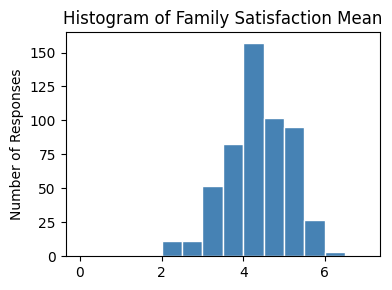

In [ ]:
import matplotlib.pyplot as plt     # import appropriate library

# create the histogram
family_df.plot(kind='hist', y='family_mean',
                  figsize=(4, 3),
                  title='Histogram of Family Satisfaction Mean',
                  ylabel='Number of Responses',
                  bins=14,
                  range=(0, 7),
                  color='steelblue',
                  edgecolor='white',
                  legend=False
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

There are a few observations we can make from the above histogram.
*  No one had lower than 2 average family satisfaction.
*  Less than 20 students had lower than 3 average family satisfaction.
*  The distribution follows a bell shape, a bit skewed to the right. More students were satisfied with their families than not.

## Practice

In [ ]:
# Determine average deviance for each student


In [ ]:
# Generate a histogram for average deviance


Add a **text block** to discuss your observations from the above results.